# Figure Generation — Sections 8 & 9
## *Geometry of the Virtue of Complexity*

Regenerates **12 figures** from the paper using the real CSV outputs from the experimentation runs.

**Inputs expected:**
- `data/all_synthetic_datarun_results.csv` — synthetic broad-grid runs (Sweeps A–D, 55 rows)
- `data/all_rff_results.csv` — historical asset-pricing runs (88 rows)

The notebook auto-detects these in `data/`, the working directory, or one level up.

**Output:** PDFs/PNGs written to `plots/`.

| # | File | Section | Description |
|---|------|---------|-------------|
| 1 | `fig_p7_1.pdf` | §8.3.1 | Synthetic drift-related Sharpe scatter |
| 2 | `fig_p6_1.png` | §8.3.2 | Matched-pair regime separation |
| 3 | `fig_p3_1.png` | §8.3.3 | Geometric metrics vs z |
| 4 | `fig_p4_2.png` | §8.3.4 | z=0 erratic vs z>0 clean peaks |
| 5 | `fig_p2_1.png` | §8.3.5 | Spectral gap cliff at k₀ |
| 6 | `fig_p5_1.png` | §8.3.6 | Effective rank collapse |
| 7 | `fig_sharpe_r2_smooth.png` | §8.3.7 | Sharpe and R² vs P̃ |
| 8 | `fig1_regime.pdf` | §9.3.1 | Regime separation (historical) |
| 9 | `fig3_zsweep.pdf` | §9.3.2 | Ridge sweep (historical) |
| 10 | `fig7_specgap.pdf` | §9.3.3 | Spectral gap cliff (historical) |
| 11 | `fig_hist_aniso.pdf` | §9.3.4 | Drift anisotropy (historical) |
| 12 | `fig_goldilocks.pdf` | §9.3.5 | Goldilocks zone (historical) |


In [1]:
import numpy as np, pandas as pd, matplotlib, matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from scipy import stats
from pathlib import Path
import warnings; warnings.filterwarnings('ignore')

matplotlib.rcParams.update({
    'font.size': 11, 'axes.titlesize': 13, 'axes.labelsize': 12,
    'legend.fontsize': 9, 'figure.dpi': 150,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3, 'grid.linestyle': '-',
})
OUT = Path('plots'); OUT.mkdir(exist_ok=True)

def find_csv(filename):
    for p in [Path('data')/filename, Path(filename),
              Path('..')/'data'/filename, Path('..')/filename]:
        if p.exists():
            try:
                df = pd.read_csv(p)
                if len(df.columns) >= 5 and len(df) > 5:
                    print(f'✓ Loaded {p}  ({len(df)} rows, {len(df.columns)} cols)')
                    return df
            except Exception:
                pass
    return None

def styled_grid(ax):
    # Apply consistent grid styling.
    ax.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
    ax.set_axisbelow(True)
print('Setup complete.')


Setup complete.


## 1 — Synthetic Data (Section 8)

Loaded from `all_synthetic_datarun_results.csv`. The CSV stores **four sweeps**:
- `sweep_A_k_z_P1024` — k varied, z ∈ {0,10,50}, P=1024 (24 rows, has d_proj, angles, anisotropy, erank, spectral gap)
- `sweep_B_P_grid` — k ∈ {12,24}, z ∈ {10,50}, P ∈ {256,1024,4096} (12 rows, Sharpe + R² + geometry)
- `sweep_C_fine_z` — k=12, P=1024, fine z grid including z=0 (7 rows, full angle metrics)
- `sweep_D_fine_P` — k ∈ {12,24}, z=10, fine P grid (12 rows, Sharpe + R² + geometry)

The checkpointed rerun now stores `avg_mean_principal_angle` and `anisotropy`, so synthetic drift anisotropy can be plotted directly.


In [2]:
# ── Load synthetic ──────────────────────────────────────────────────────
synth_df = find_csv('all_synthetic_datarun_results.csv')

if synth_df is None:
    raise FileNotFoundError(
        "all_synthetic_datarun_results.csv not found. "
        "Place it in data/ or the working directory.")

# Parse z column ("z=1e+01" → 10.0)
synth_df['z'] = synth_df['z'].astype(str).str.replace('z=', '', regex=False).astype(float)

# Use the checkpointed anisotropy when available; otherwise fall back to mean/max angle.
if 'anisotropy' in synth_df.columns:
    synth_df['rho_psi'] = synth_df['anisotropy']
elif 'avg_mean_principal_angle' in synth_df.columns:
    synth_df['rho_psi'] = np.where(
        synth_df['avg_max_principal_angle'] > 1e-8,
        synth_df['avg_mean_principal_angle'] / synth_df['avg_max_principal_angle'], np.nan)
else:
    synth_df['avg_mean_principal_angle'] = np.nan
    synth_df['rho_psi'] = np.nan
    print('⚠ synth CSV lacks anisotropy / avg_mean_principal_angle → rho_psi unavailable for synthetic.')

print(f'\nSynthetic data: {len(synth_df)} rows')
print(f'  Sweeps: {synth_df.result_set.unique().tolist()}')
print(f'  k values: {sorted(synth_df.k.unique())}')
print(f'  z values: {sorted(synth_df.z.unique())}')
synth_df.head()


✓ Loaded ../data/all_synthetic_datarun_results.csv  (55 rows, 15 cols)

Synthetic data: 55 rows
  Sweeps: ['sweep_A_k_z_P1024', 'sweep_B_P_grid', 'sweep_C_fine_z', 'sweep_D_fine_P']
  k values: [np.int64(4), np.int64(8), np.int64(12), np.int64(16), np.int64(20), np.int64(24), np.int64(28), np.int64(32)]
  z values: [np.float64(0.0), np.float64(1.0), np.float64(5.0), np.float64(10.0), np.float64(20.0), np.float64(50.0), np.float64(100.0)]


,result_set,k,P,z,avg_r2_oos,avg_sharpe,avg_subspace_stability,avg_max_principal_angle,avg_mean_principal_angle,anisotropy,angle_anisotropy_ratio,avg_geodesic_accel,avg_erank,avg_erank_collapse,avg_spectral_gap,rho_psi
0,sweep_A_k_z_P1024,4,1024,0.0,-0.070346,0.192355,0.481130,0.300797,0.147333,0.489891,0.489807,0.074358,3.620757,0.0,0.307864,0.489891
1,sweep_A_k_z_P1024,4,1024,10.0,-0.036985,0.267641,1.183575,0.625141,0.416068,0.667772,0.665559,0.104929,3.963981,0.0,0.716873,0.667772
2,sweep_A_k_z_P1024,4,1024,50.0,-0.022681,0.484484,1.302302,0.706929,0.465533,0.660085,0.658529,0.261924,3.957427,0.0,0.697103,0.660085
3,sweep_A_k_z_P1024,8,1024,0.0,-0.051082,0.434380,0.444685,0.285989,0.079880,0.279498,0.279311,0.075175,6.505457,0.0,0.108525,0.279498
4,sweep_A_k_z_P1024,8,1024,10.0,-0.017336,0.565959,1.265193,0.678746,0.278755,0.413126,0.410692,0.075932,7.663517,0.0,0.417880,0.413126


## 2 — Historical Data (Section 9)


In [3]:
# ── Load historical ─────────────────────────────────────────────────────
hist_df = find_csv('all_rff_results.csv')
if hist_df is None:
    raise FileNotFoundError(
        "all_rff_results.csv not found. Place it in data/ or the working directory.")

# Drift anisotropy ratio
hist_df['rho_psi'] = np.where(
    hist_df['avg_max_principal_angle'] > 1e-8,
    hist_df['avg_mean_principal_angle'] / hist_df['avg_max_principal_angle'], np.nan)

print(f'\nHistorical data: {len(hist_df)} rows')
print(f'  k values: {sorted(hist_df.k.unique())}')
print(f'  z values: {sorted(hist_df.z.unique())}')
print(f'  P values: {sorted(hist_df.P.unique())}')
hist_df.head()


✓ Loaded ../data/all_rff_results.csv  (88 rows, 13 cols)

Historical data: 88 rows
  k values: [np.int64(4), np.int64(8), np.int64(12), np.int64(16), np.int64(20), np.int64(24), np.int64(28), np.int64(32)]
  z values: [np.float64(0.0), np.float64(1.0), np.float64(5.0), np.float64(10.0), np.float64(20.0), np.float64(50.0), np.float64(100.0)]
  P values: [np.int64(64), np.int64(256), np.int64(1024), np.int64(4096), np.int64(6000), np.int64(8000), np.int64(10000)]


,k,P,z,run_label,avg_r2_oos,avg_sharpe,avg_subspace_stability,avg_max_principal_angle,avg_mean_principal_angle,avg_geodesic_accel,avg_erank,avg_erank_collapse,avg_spectral_gap,rho_psi
0,4,1024,0.0,FM-P2,-0.057523,0.049676,0.501935,0.321358,0.147408,0.082284,3.602775,0.0,0.312215,0.458703
1,4,1024,10.0,FM-P1,-0.032137,-0.002450,0.961432,0.552517,0.316732,0.124789,3.946938,0.0,0.671953,0.573253
2,4,1024,20.0,Run3,-0.028626,0.205029,1.207916,0.665261,0.420080,0.195350,3.949825,0.0,0.682406,0.631451
3,4,4096,10.0,Run9,-0.027108,0.211538,0.593157,0.391503,0.168522,0.127227,3.881321,0.0,0.543416,0.430449
4,4,4096,50.0,Run9,-0.027463,0.113861,0.856288,0.518116,0.264662,0.105035,3.949071,0.0,0.678160,0.510816


## 3 — Helper for OLS fit + 95% CI + correlation


In [4]:
def plot_ols_with_ci(ax, x, y, color='steelblue'):
    # Fit OLS, draw line + 95% CI band, return r and slope/intercept.
    if len(x) < 4:
        return None, None, None
    sl, ic, rv, _, _ = stats.linregress(x, y)
    xf = np.linspace(x.min(), x.max(), 100)
    yf = sl*xf + ic
    ax.plot(xf, yf, color=color, lw=2, alpha=0.85)
    n = len(x)
    se = np.sqrt(np.sum((y - (sl*x + ic))**2) / (n - 2))
    xm = x.mean()
    ci = 1.96 * se * np.sqrt(1/n + (xf - xm)**2 / np.sum((x - xm)**2))
    ax.fill_between(xf, yf - ci, yf + ci, alpha=0.18, color=color, label='95% CI for OLS fit (virtuous)')
    return sl, ic, rv


---
## 4 — Section 8 Figures (Synthetic)


### `fig_p7_1` — Synthetic Sharpe-vs-$d_{proj}$ scatter (§8.3.1 diagnostic)

This plot shows the projection-distance regime separation without an OLS fit or confidence band.  
The true synthetic anisotropy-vs-Sharpe figure is generated in the next cell using the checkpointed `anisotropy` metric.


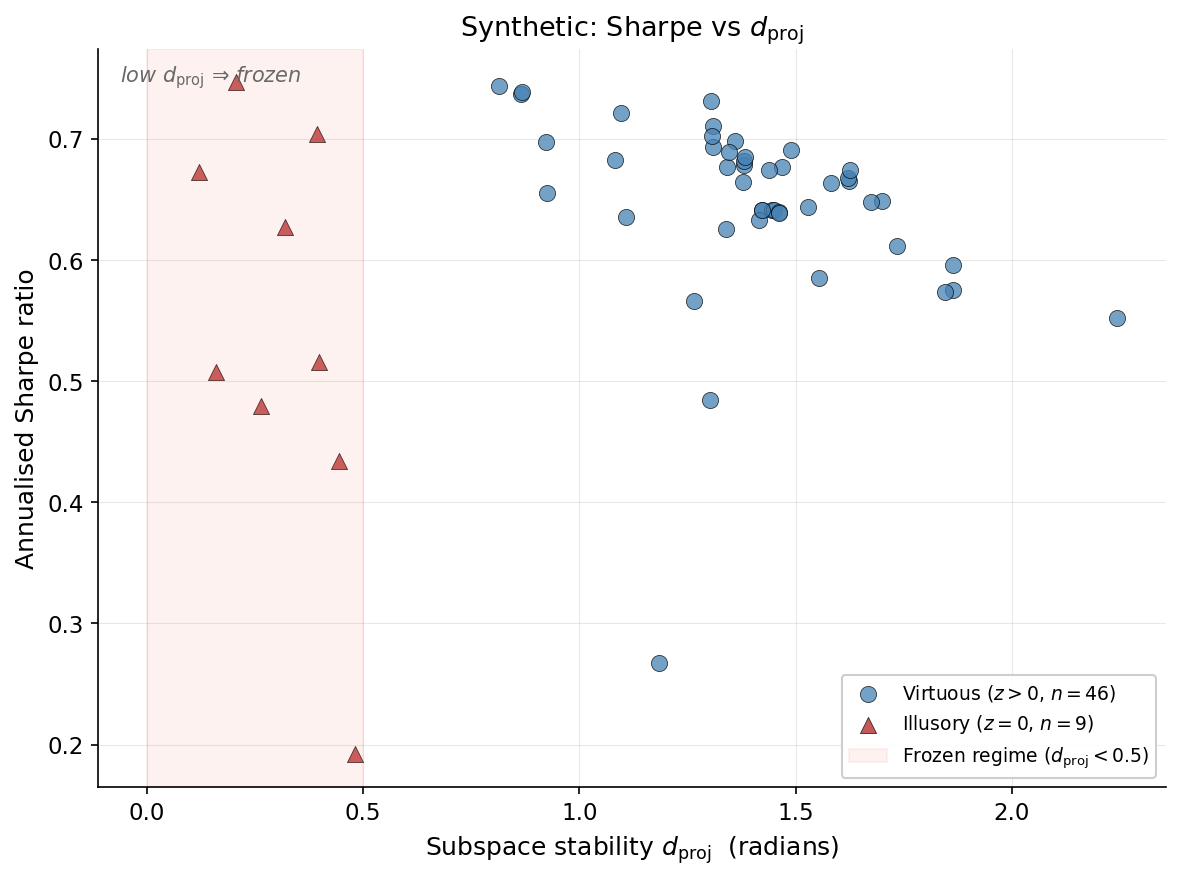

✓ fig_p7_1.pdf


In [5]:
# ── fig_p7_1: Sharpe vs d_proj on synthetic, scatter only ───────────────
fig, ax = plt.subplots(figsize=(8, 6))
sub = synth_df.dropna(subset=['avg_subspace_stability', 'avg_sharpe'])
virt = sub[sub.z > 0]
ills = sub[sub.z == 0]

ax.scatter(virt.avg_subspace_stability, virt.avg_sharpe,
           c='steelblue', marker='o', s=60, alpha=0.75,
           edgecolors='k', linewidth=0.4, label=f'Virtuous ($z>0$, $n={len(virt)}$)')
ax.scatter(ills.avg_subspace_stability, ills.avg_sharpe,
           c='firebrick', marker='^', s=60, alpha=0.75,
           edgecolors='k', linewidth=0.4, label=f'Illusory ($z=0$, $n={len(ills)}$)')

# Frozen-regime band, matching the historical regime-separation plot.
ax.axvspan(0, 0.5, alpha=0.10, color='salmon',
           label='Frozen regime ($d_{\mathrm{proj}} < 0.5$)')

ax.text(0.02, 0.98, r'low $d_{\mathrm{proj}}$ ⇒ frozen', fontsize=10,
        transform=ax.transAxes, ha='left', va='top', style='italic', color='dimgrey')

ax.set_xlabel(r'Subspace stability $d_{\mathrm{proj}}$  (radians)')
ax.set_ylabel('Annualised Sharpe ratio')
ax.set_title(r'Synthetic: Sharpe vs $d_{\mathrm{proj}}$')
ax.legend(loc='lower right', fontsize=9, framealpha=0.95)
styled_grid(ax)
fig.tight_layout(); fig.savefig(OUT/'fig_p7_1.pdf', bbox_inches='tight'); plt.show()
print('✓ fig_p7_1.pdf')


### `fig_synth_aniso` — Synthetic drift anisotropy vs Sharpe (§8.3.1)

Uses the checkpointed `anisotropy` metric, with an OLS fit and 95% confidence band on the virtuous (`z>0`) configurations.


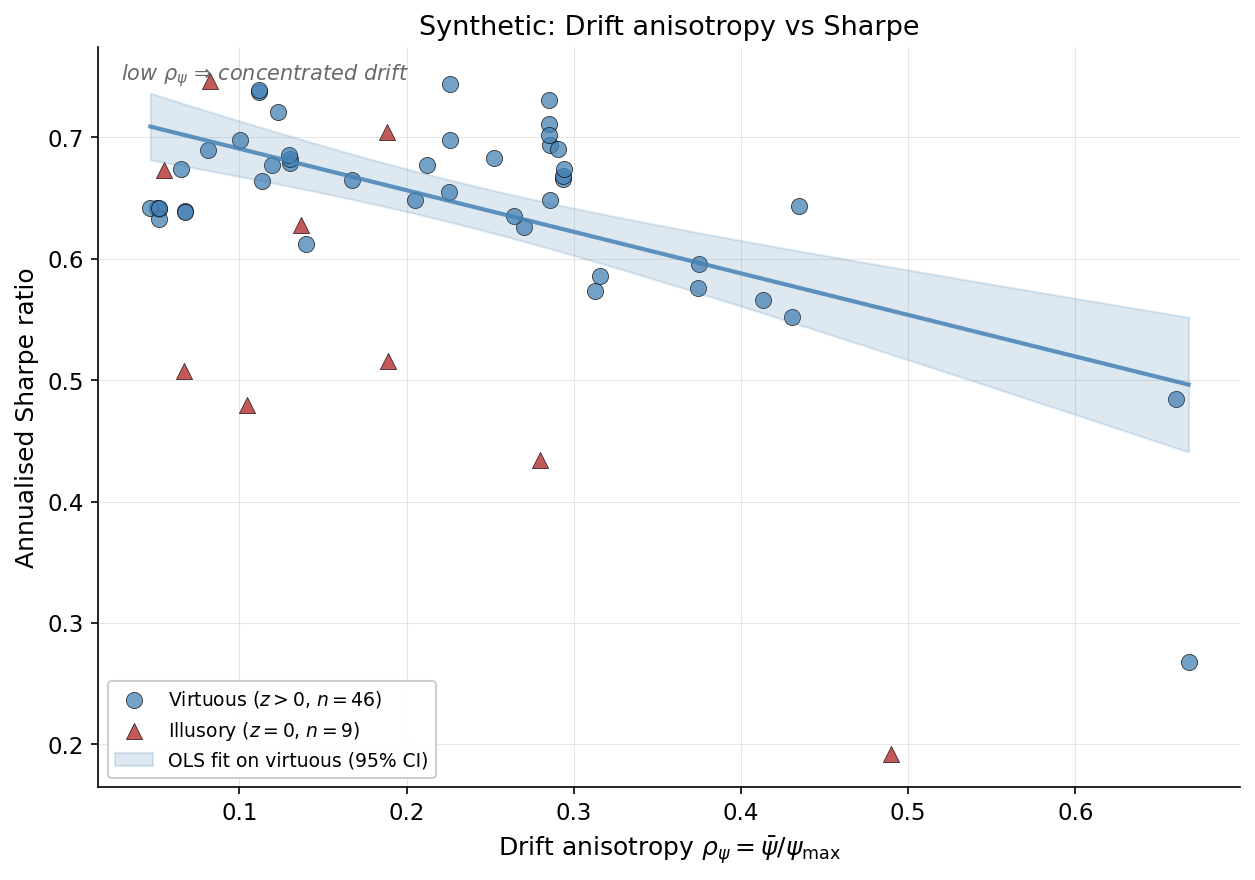

✓ fig_synth_aniso.pdf


In [6]:
# ── fig_synth_aniso: Drift anisotropy rho_psi vs Sharpe (synthetic) ──
fig, ax = plt.subplots(figsize=(8.5, 6))
sub = synth_df.dropna(subset=['rho_psi', 'avg_sharpe'])
virt = sub[sub.z > 0]
ills = sub[sub.z == 0]

ax.scatter(virt.rho_psi, virt.avg_sharpe, c='steelblue', marker='o',
           s=60, alpha=0.75, edgecolors='k', linewidth=0.4,
           label=f'Virtuous ($z>0$, $n={len(virt)}$)')
ax.scatter(ills.rho_psi, ills.avg_sharpe, c='firebrick', marker='^',
           s=60, alpha=0.75, edgecolors='k', linewidth=0.4,
           label=f'Illusory ($z=0$, $n={len(ills)}$)')

sl, ic, rv = plot_ols_with_ci(ax, virt.rho_psi.values, virt.avg_sharpe.values)
handles, labels = ax.get_legend_handles_labels()
labels = ['OLS fit on virtuous (95% CI)' if 'CI' in lbl else lbl for lbl in labels]
ax.legend(handles, labels, loc='lower left', fontsize=9, framealpha=0.95)

ax.text(0.02, 0.98, r'low $\rho_\psi$ ⇒ concentrated drift', fontsize=10,
        transform=ax.transAxes, ha='left', va='top', style='italic', color='dimgrey')

ax.set_xlabel(r'Drift anisotropy $\rho_\psi = \bar{\psi} / \psi_{\mathrm{max}}$')
ax.set_ylabel('Annualised Sharpe ratio')
ax.set_title('Synthetic: Drift anisotropy vs Sharpe')
styled_grid(ax)
fig.tight_layout(); fig.savefig(OUT/'fig_synth_aniso.pdf', bbox_inches='tight'); plt.show()
print('✓ fig_synth_aniso.pdf')


### `fig_p6_1` — Matched-pair regime separation (§8.3.2)


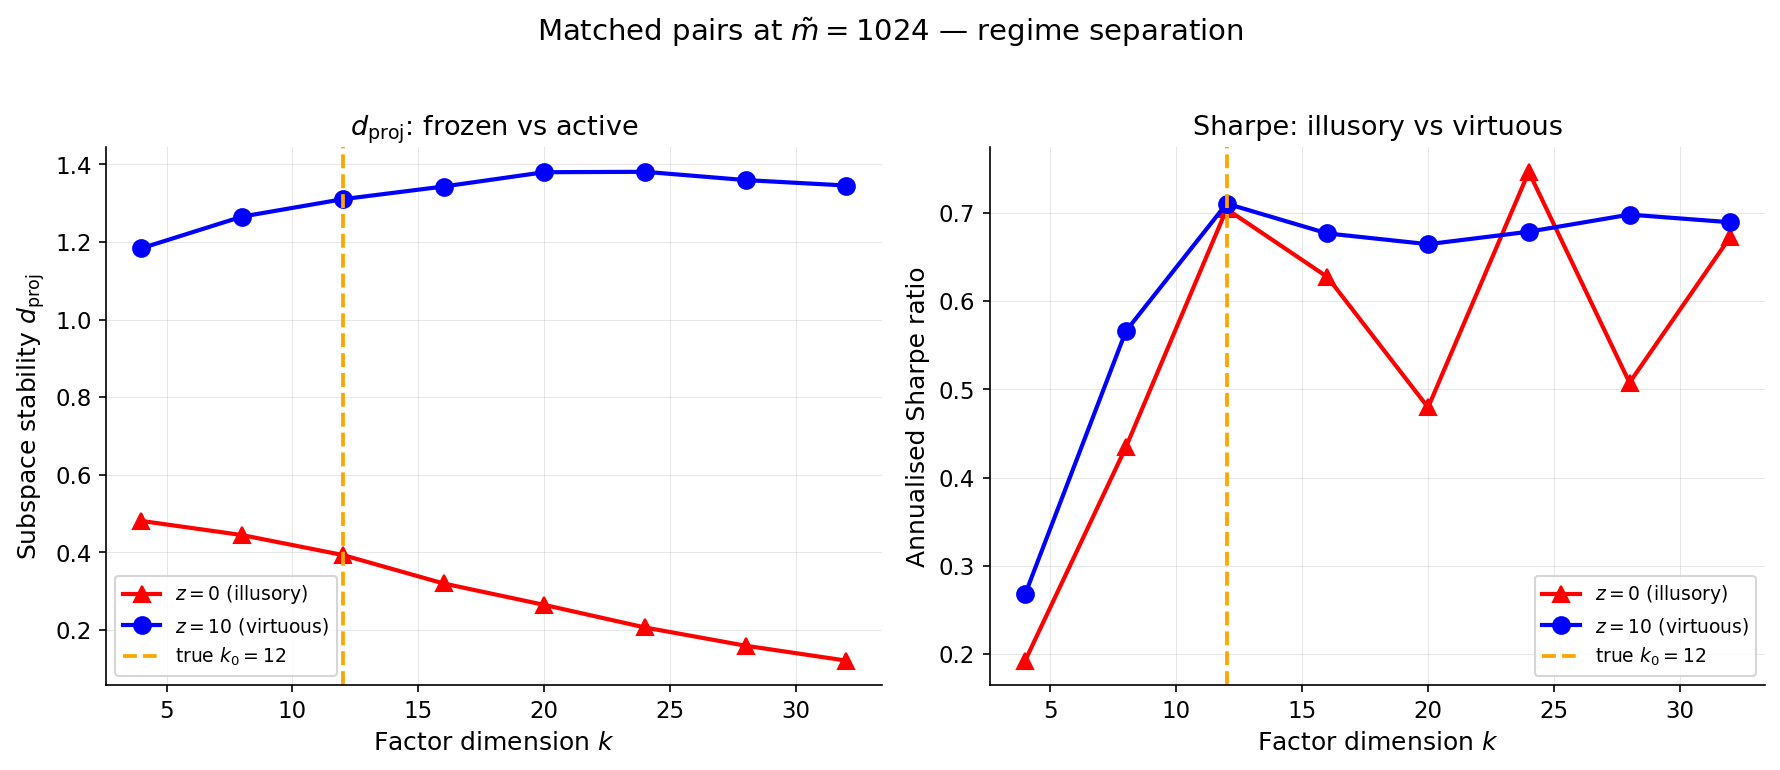

✓ fig_p6_1.png


In [7]:
# ── fig_p6_1: Matched pairs at P=1024, k varied, z=0 vs z=10 ────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5)); k0=12; P=1024
sa = synth_df[synth_df.result_set=='sweep_A_k_z_P1024']
s0 = sa[(sa.P==P) & (sa.z==0)].sort_values('k')
s10 = sa[(sa.P==P) & (sa.z==10)].sort_values('k')

# Left: d_proj
ax = axes[0]
ax.plot(s0.k, s0.avg_subspace_stability, 'r-^', ms=8, lw=2, label='$z=0$ (illusory)')
ax.plot(s10.k, s10.avg_subspace_stability, 'b-o', ms=8, lw=2, label='$z=10$ (virtuous)')
ax.axvline(k0, color='orange', ls='--', lw=1.8, label=f'true $k_0={k0}$')
ax.set_xlabel('Factor dimension $k$')
ax.set_ylabel(r'Subspace stability $d_{\mathrm{proj}}$')
ax.set_title(r'$d_{\mathrm{proj}}$: frozen vs active'); ax.legend(fontsize=9)
styled_grid(ax)

# Right: Sharpe
ax = axes[1]
ax.plot(s0.k, s0.avg_sharpe, 'r-^', ms=8, lw=2, label='$z=0$ (illusory)')
ax.plot(s10.k, s10.avg_sharpe, 'b-o', ms=8, lw=2, label='$z=10$ (virtuous)')
ax.axvline(k0, color='orange', ls='--', lw=1.8, label=f'true $k_0={k0}$')
ax.set_xlabel('Factor dimension $k$')
ax.set_ylabel('Annualised Sharpe ratio')
ax.set_title('Sharpe: illusory vs virtuous'); ax.legend(fontsize=9)
styled_grid(ax)

fig.suptitle(r'Matched pairs at $\tilde m=1024$ — regime separation',
             fontsize=14, y=1.02)
fig.tight_layout(); fig.savefig(OUT/'fig_p6_1.png', dpi=200, bbox_inches='tight'); plt.show()
print('✓ fig_p6_1.png')


### `fig_p3_1` — Geometric metrics vs z (§8.3.3)


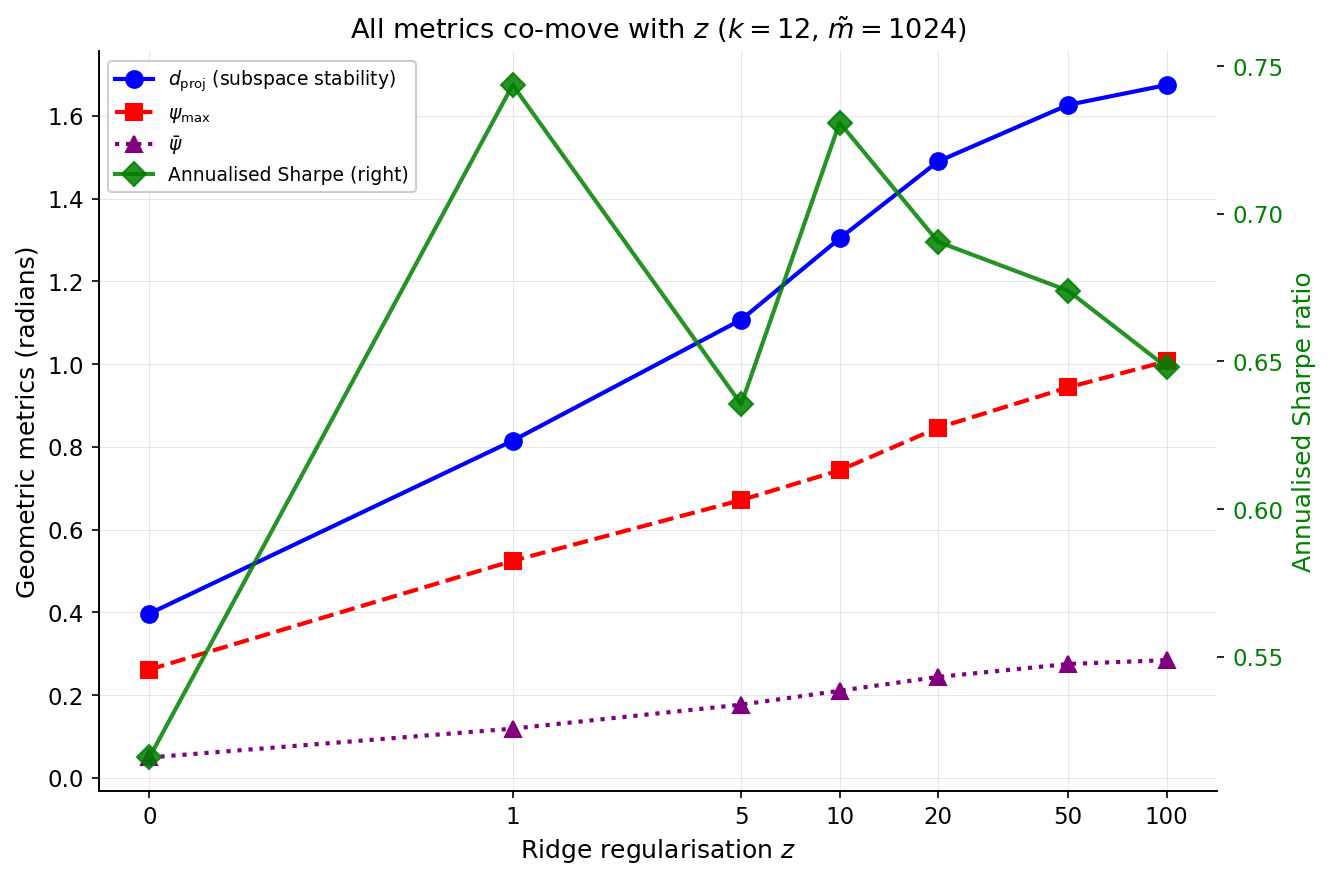

✓ fig_p3_1.png


In [8]:
# ── fig_p3_1: angles, d_proj, and Sharpe across z (k=12, P=1024) ─────
fig, ax = plt.subplots(figsize=(9, 6))
# Use Sweep C (the z-sweep at k=12 designed for this), including z=0.
sub = synth_df[synth_df.result_set.eq('sweep_C_fine_z')].sort_values('z')
sub = sub.groupby('z', as_index=False).mean(numeric_only=True)

# Geometric metrics on left axis
l1, = ax.plot(sub.z, sub.avg_subspace_stability, 'b-o', ms=8, lw=2,
              label=r'$d_{\mathrm{proj}}$ (subspace stability)')
l2, = ax.plot(sub.z, sub.avg_max_principal_angle, 'r--s', ms=8, lw=2,
              label=r'$\psi_{\mathrm{max}}$')
l3, = ax.plot(sub.z, sub.avg_mean_principal_angle, color='purple', ls=':',
              marker='^', ms=8, lw=2, label=r'$\bar\psi$')

ax.set_xscale('symlog', linthresh=1)
ax.set_xticks(sub.z.values)
ax.set_xticklabels([str(int(z)) if float(z).is_integer() else f'{z:g}' for z in sub.z.values])
ax.set_xlabel('Ridge regularisation $z$')
ax.set_ylabel('Geometric metrics (radians)')
styled_grid(ax)

# Sharpe on right axis
ax2 = ax.twinx(); ax2.grid(False)
l4, = ax2.plot(sub.z, sub.avg_sharpe, 'g-D', ms=8, lw=2, alpha=0.85,
               label='Annualised Sharpe (right)')
ax2.set_ylabel('Annualised Sharpe ratio', color='green')
ax2.tick_params(axis='y', labelcolor='green')

ax.legend(handles=[l1, l2, l3, l4], loc='upper left', fontsize=9, framealpha=0.95)
ax.set_title(r'All metrics co-move with $z$ ($k=12$, $\tilde m=1024$)')
fig.tight_layout(); fig.savefig(OUT/'fig_p3_1.png', dpi=200, bbox_inches='tight'); plt.show()
print('✓ fig_p3_1.png')


### `fig_p4_2` — z=0 erratic vs z>0 clean peaks (§8.3.4)


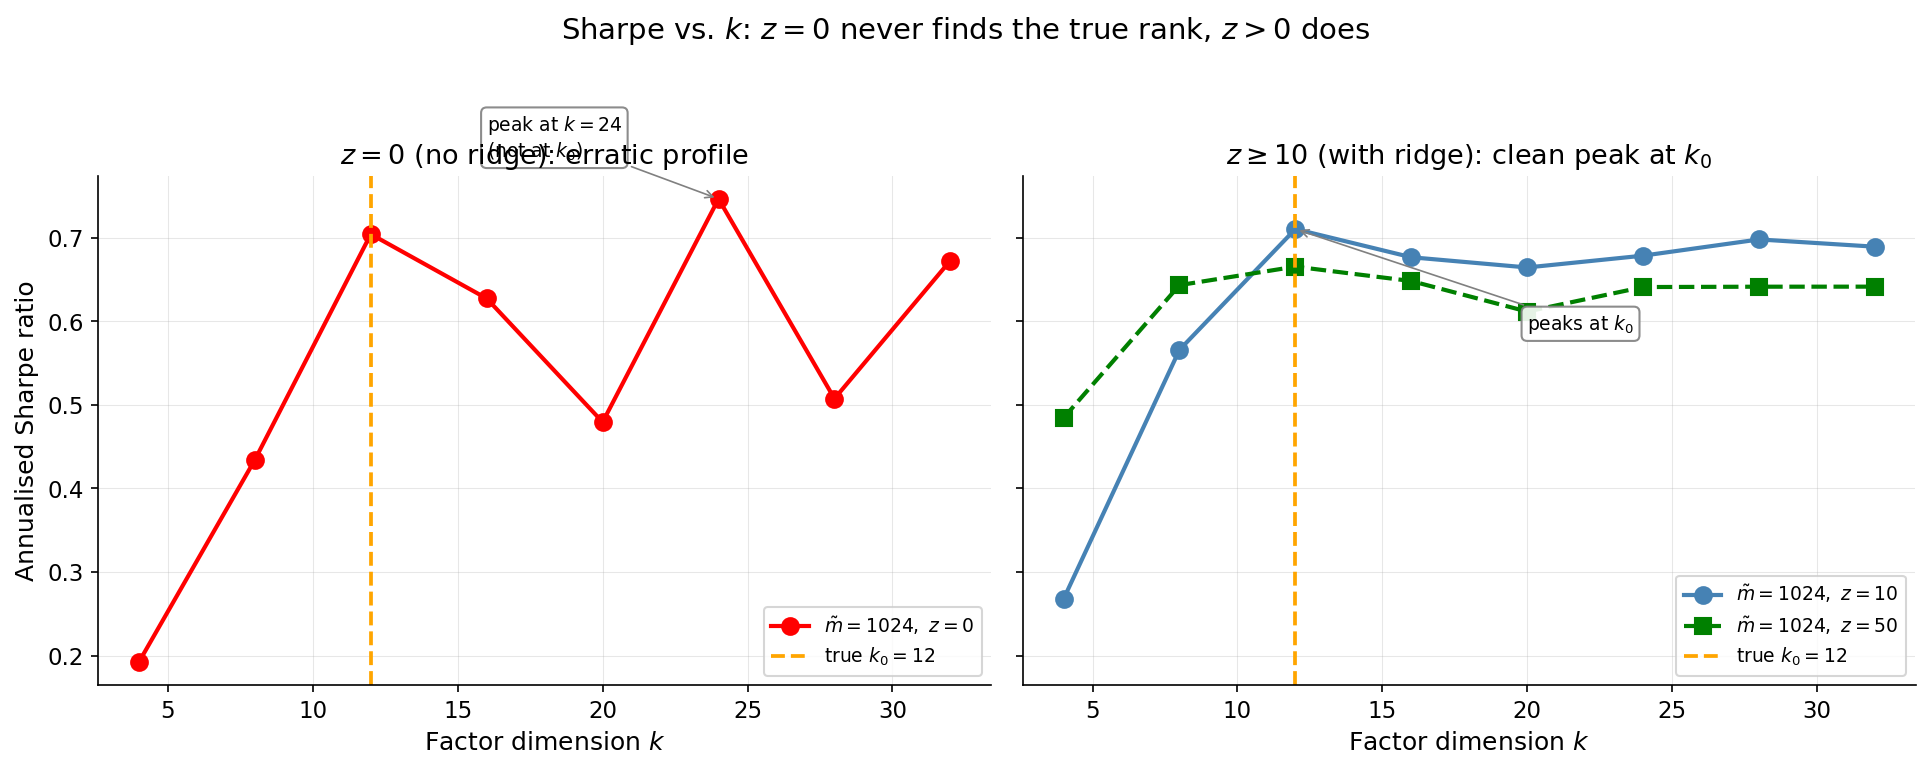

✓ fig_p4_2.png


In [9]:
# ── fig_p4_2: Sharpe vs k for z=0 (left) and z>0 (right) ────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True); k0=12; P=1024

# Left: z=0
ax = axes[0]
sa = synth_df[synth_df.result_set=='sweep_A_k_z_P1024']
sub = sa[(sa.P==P) & (sa.z==0)].sort_values('k')
ax.plot(sub.k, sub.avg_sharpe, 'r-o', ms=8, lw=2, label=f'$\\tilde m={P},\\ z=0$')
ax.axvline(k0, color='orange', ls='--', lw=1.8, label=f'true $k_0={k0}$')
peak_k = sub.loc[sub.avg_sharpe.idxmax(), 'k']
peak_s = sub.avg_sharpe.max()
# Annotation positioned to NOT overlap the peak point or right legend
ax.annotate(f'peak at $k={int(peak_k)}$\n(not at $k_0$)',
            xy=(peak_k, peak_s),
            xytext=(peak_k - 8, peak_s + 0.05),
            fontsize=9, ha='left',
            arrowprops=dict(arrowstyle='->', color='grey', lw=0.8),
            bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='grey', alpha=0.9))
ax.set_xlabel('Factor dimension $k$')
ax.set_ylabel('Annualised Sharpe ratio')
ax.set_title('$z=0$ (no ridge): erratic profile')
ax.legend(loc='lower right', fontsize=9)
styled_grid(ax)

# Right: z >= 10
ax = axes[1]
for zv, c, m, ls in [(10, 'steelblue', 'o', '-'), (50, 'green', 's', '--')]:
    s = sa[(sa.P==P) & (sa.z==zv)].sort_values('k')
    ax.plot(s.k, s.avg_sharpe, color=c, marker=m, ms=8, lw=2, ls=ls,
            label=f'$\\tilde m={P},\\ z={zv}$')
ax.axvline(k0, color='orange', ls='--', lw=1.8, label=f'true $k_0={k0}$')
# Anchor annotation away from data peak
sub10 = sa[(sa.P==P) & (sa.z==10)].sort_values('k')
peak10 = sub10.loc[sub10.avg_sharpe.idxmax()]
ax.annotate('peaks at $k_0$',
            xy=(peak10.k, peak10.avg_sharpe),
            xytext=(peak10.k + 8, peak10.avg_sharpe - 0.12),
            fontsize=9, ha='left',
            arrowprops=dict(arrowstyle='->', color='grey', lw=0.8),
            bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='grey', alpha=0.9))
ax.set_xlabel('Factor dimension $k$')
ax.set_title(r'$z\geq 10$ (with ridge): clean peak at $k_0$')
ax.legend(loc='lower right', fontsize=9)
styled_grid(ax)

fig.suptitle(r'Sharpe vs. $k$: $z=0$ never finds the true rank, $z>0$ does',
             fontsize=14, y=1.02)
fig.tight_layout(); fig.savefig(OUT/'fig_p4_2.png', dpi=200, bbox_inches='tight'); plt.show()
print('✓ fig_p4_2.png')


### `fig_p2_1` — Spectral gap cliff (§8.3.5)


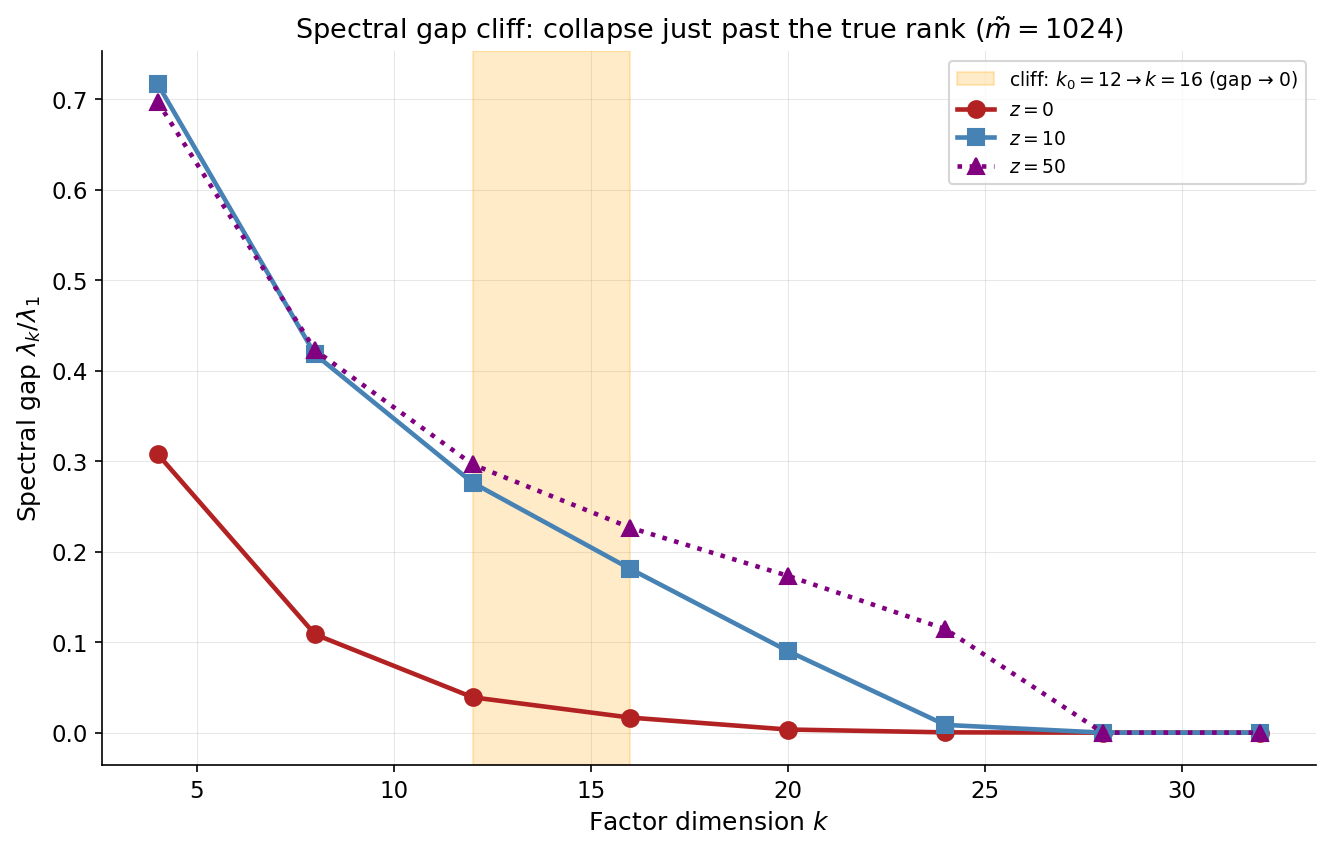

✓ fig_p2_1.png


In [10]:
# ── fig_p2_1: Spectral gap vs k with cliff highlighted at k=12..16 ──────
fig, ax = plt.subplots(figsize=(9, 5.8)); k0 = 12; P = 1024

# Highlight the collapse band: k=12 to k=16 (where it goes to zero)
ax.axvspan(k0, 16, alpha=0.22, color='orange', label=f'cliff: $k_0={k0}\\to k=16$ (gap → 0)')

sa = synth_df[synth_df.result_set=='sweep_A_k_z_P1024']
for zv, c, m, ls in [(0, 'firebrick', 'o', '-'),
                      (10, 'steelblue', 's', '-'),
                      (50, 'purple', '^', ':')]:
    s = sa[(sa.P==P) & (sa.z==zv)].sort_values('k')
    if len(s) > 0:
        ax.plot(s.k, s.avg_spectral_gap, color=c, marker=m, ms=8, lw=2.2, ls=ls,
                label=f'$z={zv}$')

ax.set_xlabel('Factor dimension $k$')
ax.set_ylabel(r'Spectral gap $\lambda_k / \lambda_1$')
ax.set_title(r'Spectral gap cliff: collapse just past the true rank ($\tilde m=1024$)')
ax.legend(fontsize=9, loc='upper right')
styled_grid(ax)
fig.tight_layout(); fig.savefig(OUT/'fig_p2_1.png', dpi=200, bbox_inches='tight'); plt.show()
print('✓ fig_p2_1.png')


### `fig_p5_1` — Effective rank collapse (§8.3.6)


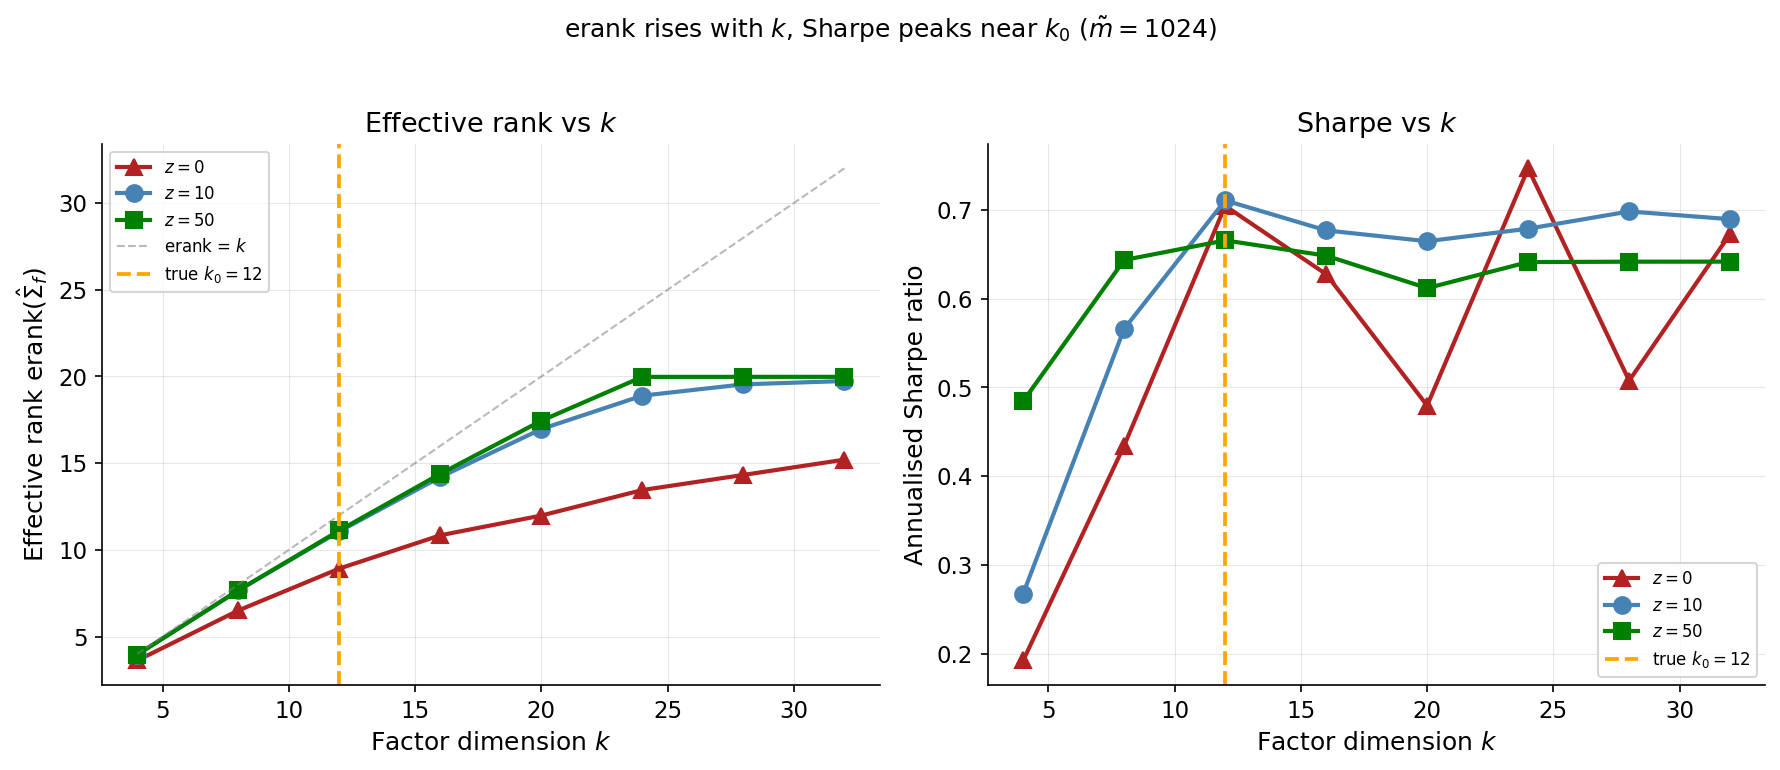

✓ fig_p5_1.png


In [11]:
# ── fig_p5_1: Effective rank and Sharpe vs k ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5)); k0 = 12; P = 1024

# Left: erank vs k
ax = axes[0]
sa = synth_df[synth_df.result_set=='sweep_A_k_z_P1024']
for zv, c, m in [(0, 'firebrick', '^'), (10, 'steelblue', 'o'), (50, 'green', 's')]:
    s = sa[(sa.P==P) & (sa.z==zv)].sort_values('k')
    if len(s) > 0:
        ax.plot(s.k, s.avg_erank, color=c, marker=m, ms=8, lw=2, label=f'$z={zv}$')
# Identity line: erank = k
kr = np.arange(synth_df.k.min(), synth_df.k.max() + 1)
ax.plot(kr, kr, 'grey', ls='--', lw=1, alpha=0.55, label='erank = $k$')
ax.axvline(k0, color='orange', ls='--', lw=1.8, label=f'true $k_0={k0}$')
ax.set_xlabel('Factor dimension $k$')
ax.set_ylabel(r'Effective rank erank($\hat\Sigma_f$)')
ax.set_title('Effective rank vs $k$')
ax.legend(fontsize=8); styled_grid(ax)

# Right: Sharpe vs k
ax = axes[1]
for zv, c, m in [(0, 'firebrick', '^'), (10, 'steelblue', 'o'), (50, 'green', 's')]:
    s = sa[(sa.P==P) & (sa.z==zv)].sort_values('k')
    if len(s) > 0:
        ax.plot(s.k, s.avg_sharpe, color=c, marker=m, ms=8, lw=2, label=f'$z={zv}$')
ax.axvline(k0, color='orange', ls='--', lw=1.8, label=f'true $k_0={k0}$')
ax.set_xlabel('Factor dimension $k$')
ax.set_ylabel('Annualised Sharpe ratio')
ax.set_title('Sharpe vs $k$')
ax.legend(fontsize=8); styled_grid(ax)

fig.suptitle(r'erank rises with $k$, Sharpe peaks near $k_0$ ($\tilde m=1024$)',
             fontsize=12, y=1.02)
fig.tight_layout(); fig.savefig(OUT/'fig_p5_1.png', dpi=200, bbox_inches='tight'); plt.show()
print('✓ fig_p5_1.png')


### `fig_sharpe_r2_smooth` — Sharpe and OOS R² vs P̃ (§8.3.7)

Uses **Sweep D** (k ∈ {12,24}, z=10, P ∈ {128,256,512,1024,2048,4096} — 12 rows).  
This is the broadest P-sweep available in the synthetic CSV with R² values.


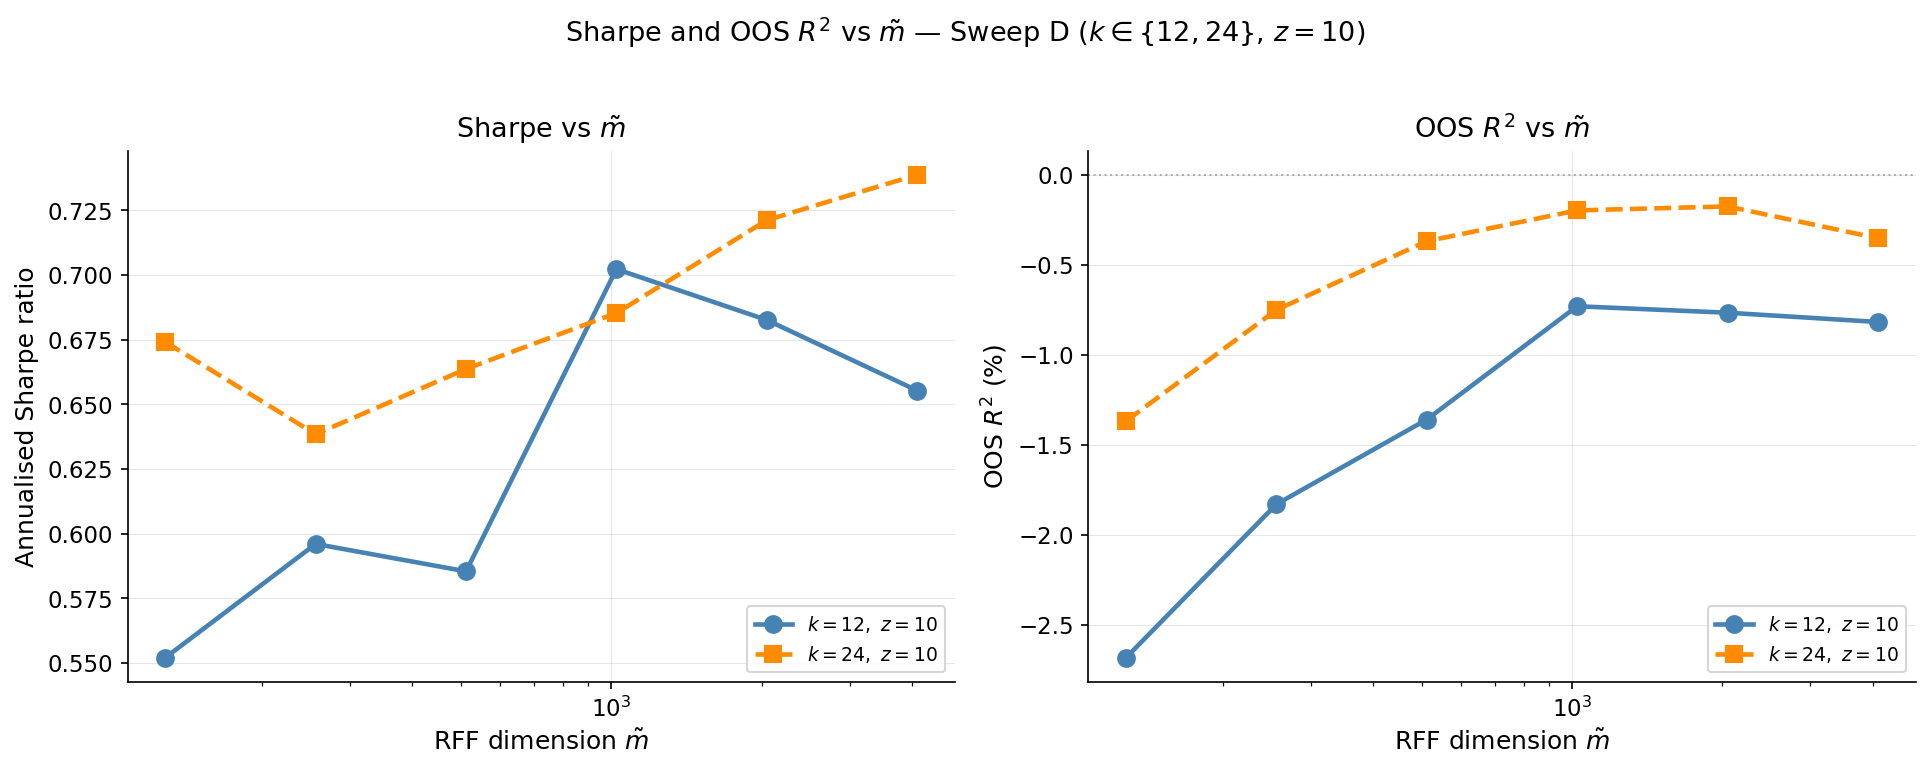

✓ fig_sharpe_r2_smooth.png


In [12]:
# ── fig_sharpe_r2_smooth: Sharpe and OOS R² vs P (Sweep D) ──────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5)); z = 10
sweep_D = synth_df[synth_df.result_set == 'sweep_D_fine_P'].copy()

style = {12: ('steelblue', 'o', '-'), 24: ('darkorange', 's', '--')}
for kv, (c, m, ls) in style.items():
    s = sweep_D[(sweep_D.k == kv) & (sweep_D.z == z)].sort_values('P')
    if len(s) < 2: continue
    axes[0].plot(s.P, s.avg_sharpe, color=c, marker=m, ms=8, lw=2.2, ls=ls,
                 label=f'$k={kv},\\ z={z}$')
    axes[1].plot(s.P, s.avg_r2_oos * 100, color=c, marker=m, ms=8, lw=2.2, ls=ls,
                 label=f'$k={kv},\\ z={z}$')

axes[0].set_xscale('log'); axes[0].set_xlabel(r'RFF dimension $\tilde m$')
axes[0].set_ylabel('Annualised Sharpe ratio')
axes[0].set_title(r'Sharpe vs $\tilde m$')
axes[0].legend(fontsize=9, loc='lower right'); styled_grid(axes[0])

axes[1].set_xscale('log'); axes[1].set_xlabel(r'RFF dimension $\tilde m$')
axes[1].set_ylabel(r'OOS $R^2$ (%)')
axes[1].set_title(r'OOS $R^2$ vs $\tilde m$')
axes[1].axhline(0, color='grey', ls=':', lw=1, alpha=0.6)
axes[1].legend(fontsize=9, loc='lower right'); styled_grid(axes[1])

fig.suptitle(r'Sharpe and OOS $R^2$ vs $\tilde m$ — Sweep D ($k\in\{12,24\}$, $z=10$)',
             fontsize=13, y=1.02)
fig.tight_layout(); fig.savefig(OUT/'fig_sharpe_r2_smooth.png', dpi=200, bbox_inches='tight')
plt.show(); print('✓ fig_sharpe_r2_smooth.png')


---
## 5 — Section 9 Figures (Historical)


### `fig1_regime` — Regime separation (§9.3.1)


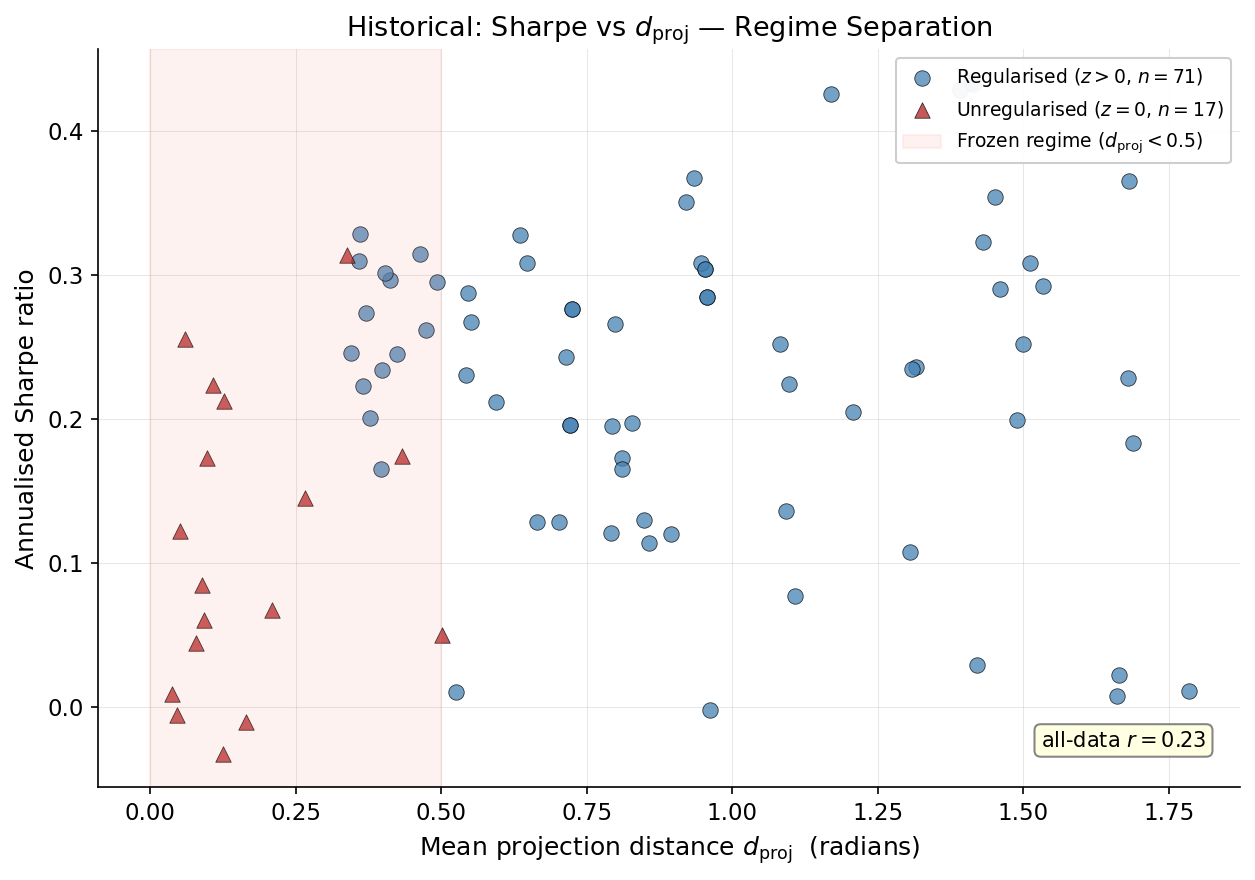

✓ fig1_regime.pdf


In [13]:
# ── fig1_regime: Sharpe vs d_proj (historical) ───────────────────────────
fig, ax = plt.subplots(figsize=(8.5, 6))
virt = hist_df[hist_df.z > 0]
ills = hist_df[hist_df.z == 0]

ax.scatter(virt.avg_subspace_stability, virt.avg_sharpe, c='steelblue', marker='o',
           s=55, alpha=0.75, edgecolors='k', linewidth=0.4,
           label=f'Regularised ($z>0$, $n={len(virt)}$)')
ax.scatter(ills.avg_subspace_stability, ills.avg_sharpe, c='firebrick', marker='^',
           s=55, alpha=0.75, edgecolors='k', linewidth=0.4,
           label=f'Unregularised ($z=0$, $n={len(ills)}$)')

# Frozen-regime band
ax.axvspan(0, 0.5, alpha=0.10, color='salmon', label='Frozen regime ($d_{\\mathrm{proj}} < 0.5$)')

# Overall correlation
all_valid = hist_df.dropna(subset=['avg_subspace_stability', 'avg_sharpe'])
r_all = np.corrcoef(all_valid.avg_subspace_stability, all_valid.avg_sharpe)[0, 1]
ax.text(0.97, 0.05, f'all-data $r = {r_all:.2f}$', fontsize=10,
        transform=ax.transAxes, ha='right', va='bottom',
        bbox=dict(boxstyle='round,pad=0.3', fc='lightyellow', ec='grey', alpha=0.95))

ax.set_xlabel(r'Mean projection distance $d_{\mathrm{proj}}$  (radians)')
ax.set_ylabel('Annualised Sharpe ratio')
ax.set_title(r'Historical: Sharpe vs $d_{\mathrm{proj}}$ — Regime Separation')
ax.legend(loc='upper right', fontsize=9, framealpha=0.95)
styled_grid(ax)
fig.tight_layout(); fig.savefig(OUT/'fig1_regime.pdf', bbox_inches='tight'); plt.show()
print('✓ fig1_regime.pdf')


### `fig3_zsweep` — Ridge sweep (§9.3.2)


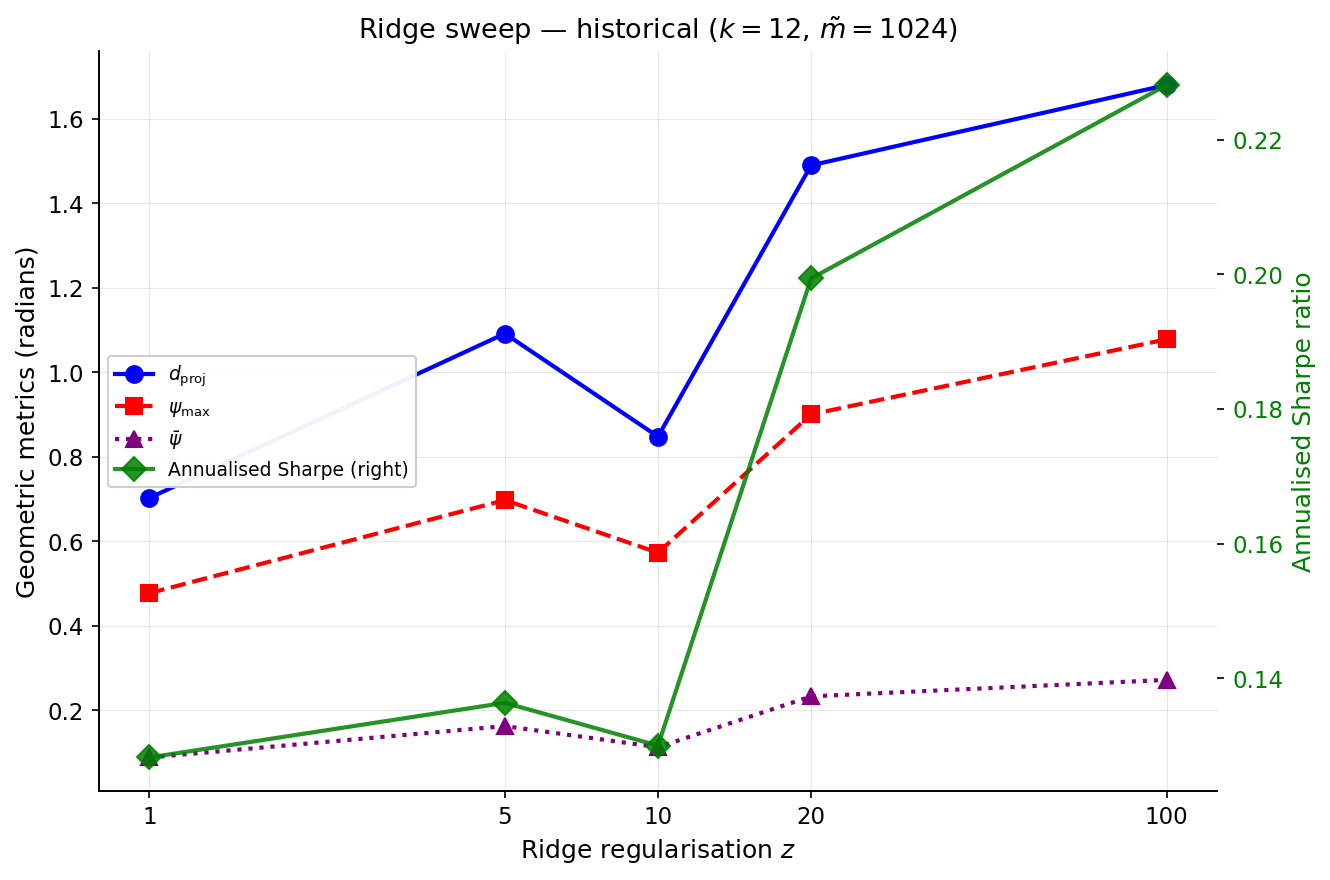

✓ fig3_zsweep.pdf


In [14]:
# ── fig3_zsweep: Ridge sweep at k=12, P=1024 (historical) ───────────────
fig, ax = plt.subplots(figsize=(9, 6))
sub = hist_df[(hist_df.k == 12) & (hist_df.P == 1024) & (hist_df.z > 0)].sort_values('z')
# average duplicates if any (multiple runs at same z)
sub = sub.groupby('z', as_index=False).mean(numeric_only=True)

if len(sub) > 1:
    l1, = ax.plot(sub.z, sub.avg_subspace_stability, 'b-o', ms=8, lw=2,
                  label=r'$d_{\mathrm{proj}}$')
    l2, = ax.plot(sub.z, sub.avg_max_principal_angle, 'r--s', ms=8, lw=2,
                  label=r'$\psi_{\mathrm{max}}$')
    l3, = ax.plot(sub.z, sub.avg_mean_principal_angle, color='purple', ls=':',
                  marker='^', ms=8, lw=2, label=r'$\bar\psi$')
    ax.set_xscale('symlog', linthresh=1)
    ax.set_xticks(sub.z.values)
    ax.set_xticklabels([str(int(z)) if float(z).is_integer() else f'{z:g}' for z in sub.z.values])
    ax.set_xlabel('Ridge regularisation $z$')
    ax.set_ylabel('Geometric metrics (radians)')
    styled_grid(ax)

    ax2 = ax.twinx(); ax2.grid(False)
    l4, = ax2.plot(sub.z, sub.avg_sharpe, 'g-D', ms=8, lw=2, alpha=0.85,
                   label='Annualised Sharpe (right)')
    ax2.set_ylabel('Annualised Sharpe ratio', color='green')
    ax2.tick_params(axis='y', labelcolor='green')
    ax.legend(handles=[l1, l2, l3, l4], loc='center left', fontsize=9, framealpha=0.95)

ax.set_title(r'Ridge sweep — historical ($k=12$, $\tilde m=1024$)')
fig.tight_layout(); fig.savefig(OUT/'fig3_zsweep.pdf', bbox_inches='tight'); plt.show()
print('✓ fig3_zsweep.pdf')


### `fig7_specgap` — Spectral gap cliff (§9.3.3)


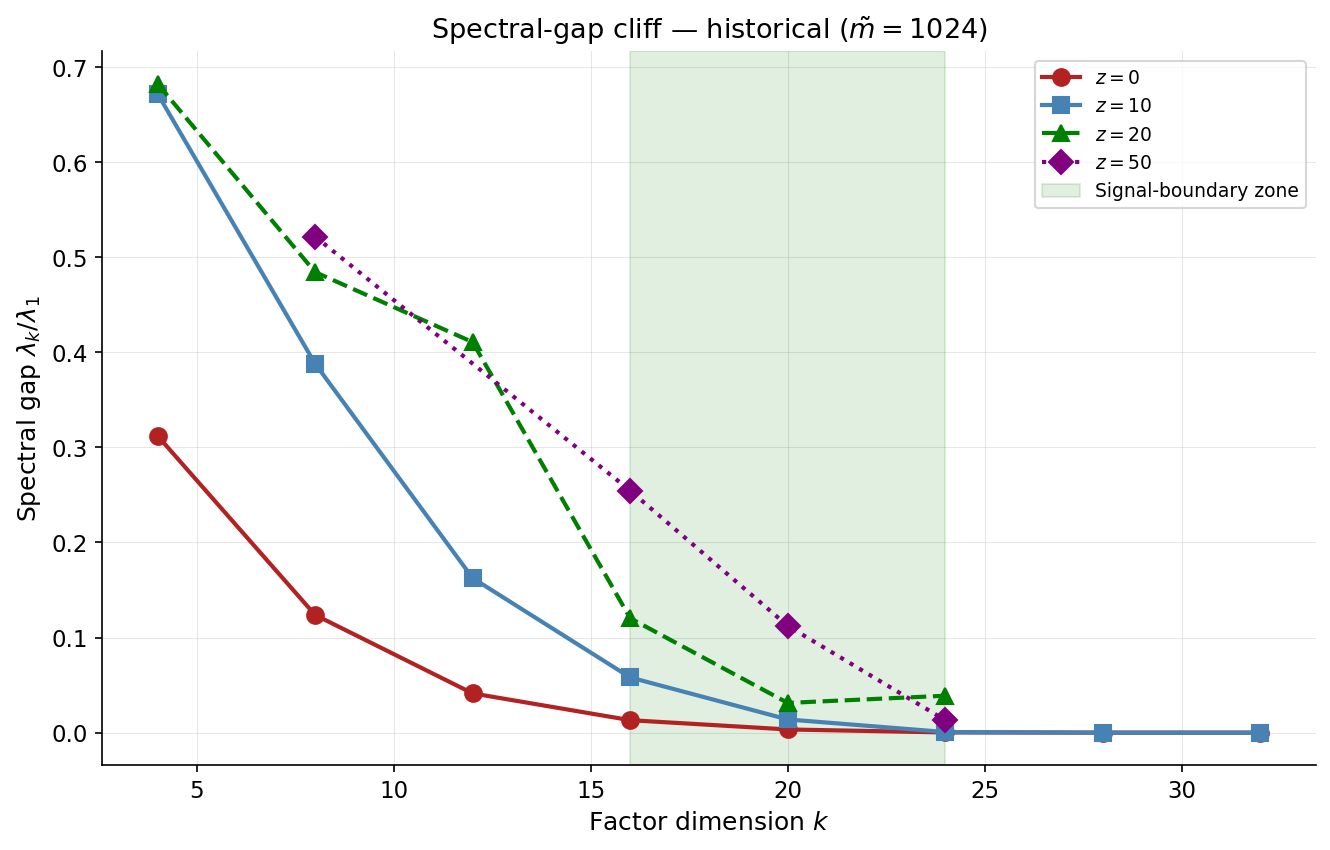

✓ fig7_specgap.pdf


In [15]:
# ── fig7_specgap: Historical spectral gap vs k ──────────────────────────
fig, ax = plt.subplots(figsize=(9, 5.8)); P = 1024

for zv, c, m, ls in [(0, 'firebrick', 'o', '-'), (10, 'steelblue', 's', '-'),
                      (20, 'green', '^', '--'), (50, 'purple', 'D', ':')]:
    s = hist_df[(hist_df.P == P) & (hist_df.z == zv)].sort_values('k')
    s = s.groupby('k', as_index=False).mean(numeric_only=True)
    if len(s) > 1:
        ax.plot(s.k, s.avg_spectral_gap, color=c, marker=m, ms=8, lw=2, ls=ls,
                label=f'$z={zv}$')

# Highlight a soft signal-boundary band
ax.axvspan(16, 24, alpha=0.12, color='green', label='Signal-boundary zone')
ax.set_xlabel('Factor dimension $k$')
ax.set_ylabel(r'Spectral gap $\lambda_k / \lambda_1$')
ax.set_title(r'Spectral-gap cliff — historical ($\tilde m=1024$)')
ax.legend(fontsize=9); styled_grid(ax)
fig.tight_layout(); fig.savefig(OUT/'fig7_specgap.pdf', bbox_inches='tight'); plt.show()
print('✓ fig7_specgap.pdf')


### `fig_hist_aniso` — Drift anisotropy, historical (§9.3.4)


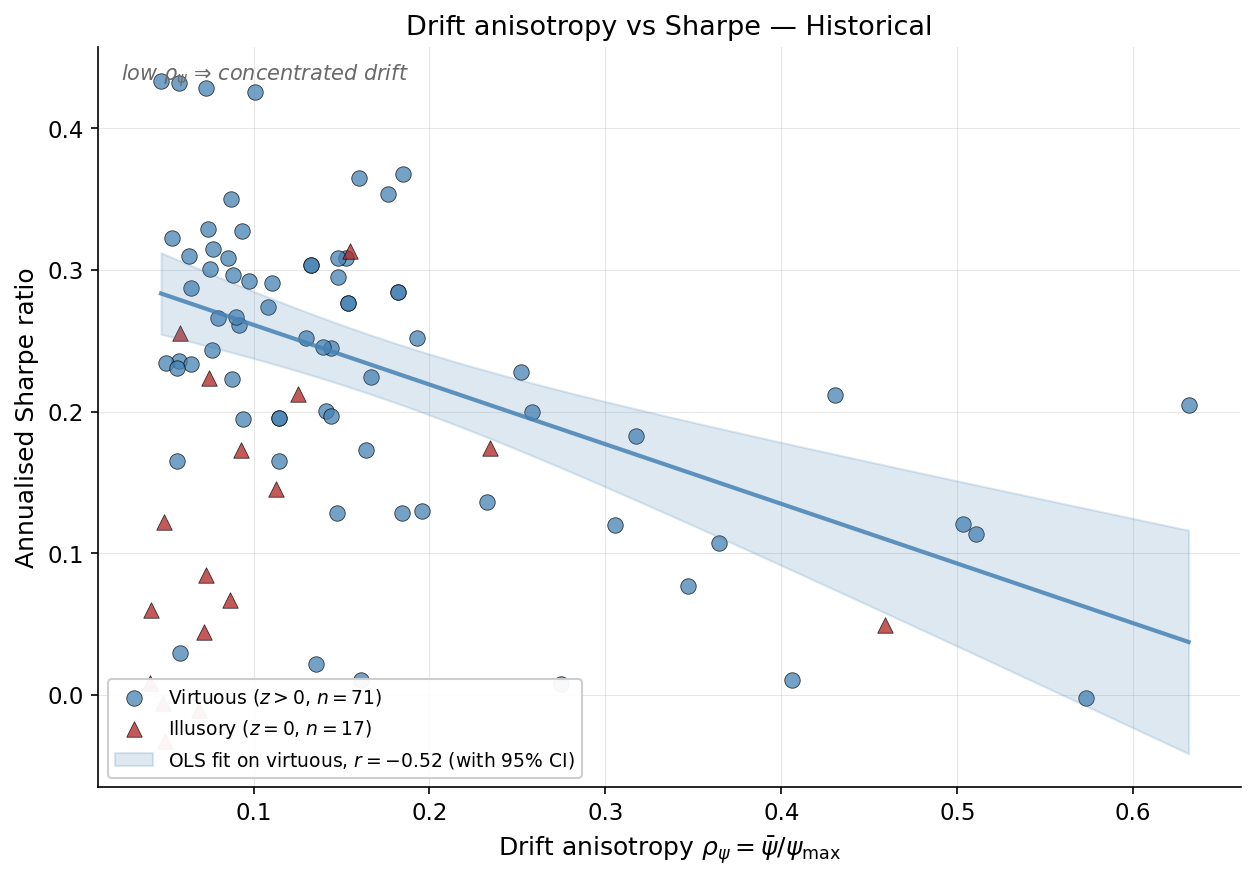

✓ fig_hist_aniso.pdf


In [16]:
# ── fig_hist_aniso: Drift anisotropy ρ_ψ vs Sharpe (historical) ─────────
fig, ax = plt.subplots(figsize=(8.5, 6))
virt = hist_df[hist_df.z > 0].dropna(subset=['rho_psi', 'avg_sharpe'])
ills = hist_df[hist_df.z == 0].dropna(subset=['rho_psi', 'avg_sharpe'])

ax.scatter(virt.rho_psi, virt.avg_sharpe, c='steelblue', marker='o',
           s=55, alpha=0.75, edgecolors='k', linewidth=0.4,
           label=f'Virtuous ($z>0$, $n={len(virt)}$)')
ax.scatter(ills.rho_psi, ills.avg_sharpe, c='firebrick', marker='^',
           s=55, alpha=0.75, edgecolors='k', linewidth=0.4,
           label=f'Illusory ($z=0$, $n={len(ills)}$)')

# OLS fit + 95% CI on virtuous
sl, ic, rv = plot_ols_with_ci(ax, virt.rho_psi.values, virt.avg_sharpe.values)

# Restyle legend so OLS line entry mentions r
handles, labels = ax.get_legend_handles_labels()
new_labels = []
for lbl in labels:
    if 'CI' in lbl and rv is not None:
        new_labels.append(f'OLS fit on virtuous, $r = {rv:.2f}$ (with 95% CI)')
    else:
        new_labels.append(lbl)
ax.legend(handles, new_labels, loc='lower left', fontsize=9, framealpha=0.95)

ax.text(0.02, 0.98, r'low $\rho_\psi$ ⇒ concentrated drift', fontsize=10,
        transform=ax.transAxes, ha='left', va='top', style='italic', color='dimgrey')

ax.set_xlabel(r'Drift anisotropy $\rho_\psi = \bar\psi / \psi_{\max}$')
ax.set_ylabel('Annualised Sharpe ratio')
ax.set_title('Drift anisotropy vs Sharpe — Historical')
styled_grid(ax)
fig.tight_layout(); fig.savefig(OUT/'fig_hist_aniso.pdf', bbox_inches='tight'); plt.show()
print('✓ fig_hist_aniso.pdf')


### `fig_goldilocks` — Goldilocks zone (§9.3.5)


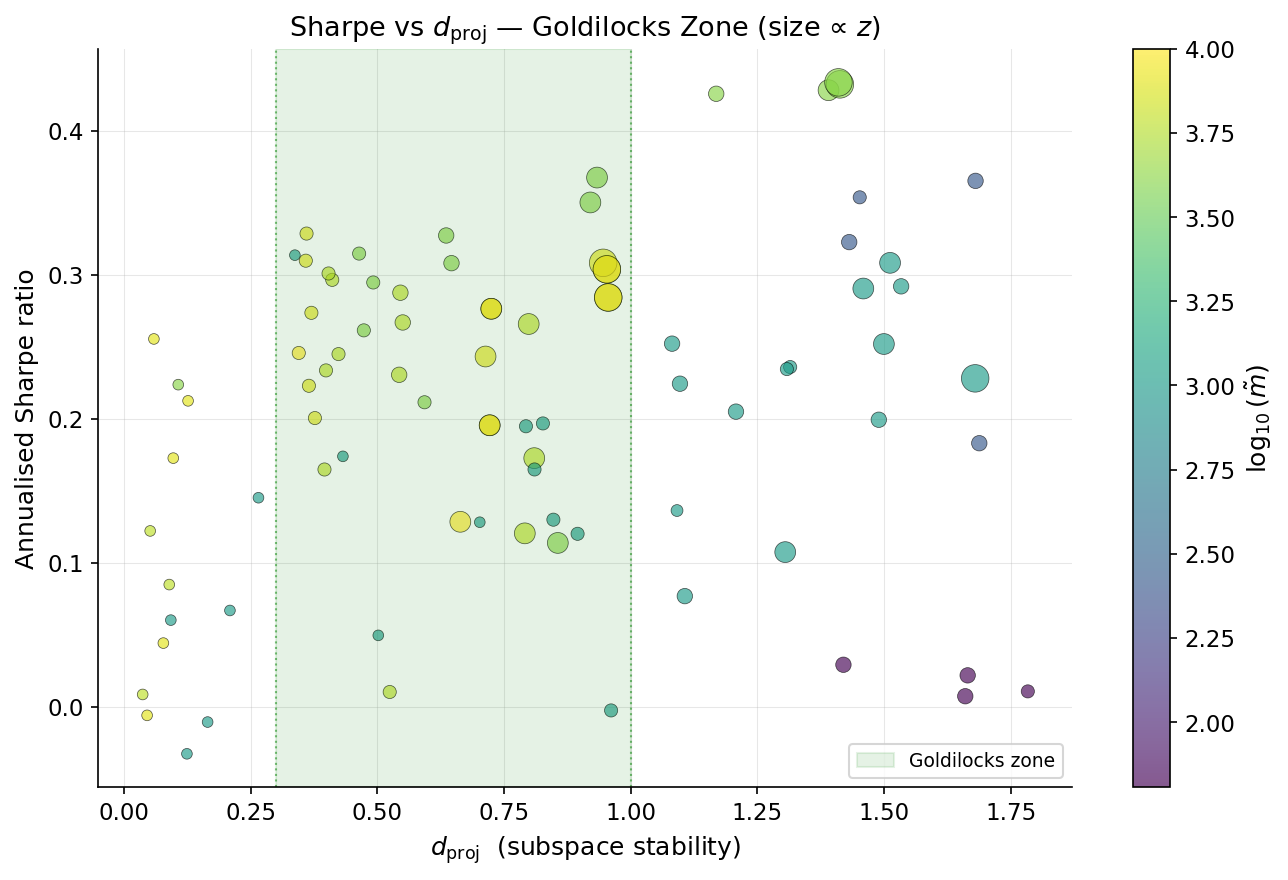

✓ fig_goldilocks.pdf


In [17]:
# ── fig_goldilocks: Sharpe vs d_proj coloured by P ──────────────────────
fig, ax = plt.subplots(figsize=(9, 6))
df = hist_df.dropna(subset=['avg_subspace_stability', 'avg_sharpe']).copy()

norm = Normalize(vmin=np.log10(64), vmax=np.log10(10000))
sc = ax.scatter(df.avg_subspace_stability, df.avg_sharpe,
                c=np.log10(df.P), cmap='viridis', norm=norm,
                s=df.z.clip(1, 100) * 1.5 + 25,
                alpha=0.65, edgecolors='k', linewidth=0.35)
plt.colorbar(sc, ax=ax, label=r'$\log_{10}(\tilde m)$')

# Goldilocks band (where regularised points cluster with high Sharpe)
ax.axvspan(0.3, 1.0, alpha=0.10, color='green', label='Goldilocks zone')
ax.axvline(0.3, color='green', ls=':', lw=1, alpha=0.5)
ax.axvline(1.0, color='green', ls=':', lw=1, alpha=0.5)

ax.set_xlabel(r'$d_{\mathrm{proj}}$  (subspace stability)')
ax.set_ylabel('Annualised Sharpe ratio')
ax.set_title(r'Sharpe vs $d_{\mathrm{proj}}$ — Goldilocks Zone (size ∝ $z$)')
ax.legend(loc='lower right', fontsize=9)
styled_grid(ax)
fig.tight_layout(); fig.savefig(OUT/'fig_goldilocks.pdf', bbox_inches='tight'); plt.show()
print('✓ fig_goldilocks.pdf')


---
## 6 — Per-figure status

| # | Figure | Status | Notes |
|---|--------|--------|-------|
| 1 | `fig_p7_1.pdf` | ✓ Real | Synthetic Sharpe vs `d_proj`, scatter only. |
| 1b | `fig_synth_aniso.pdf` | ✓ Real | Synthetic drift anisotropy from checkpointed `anisotropy`; OLS fit + 95% CI on virtuous points. |
| 2 | `fig_p6_1.png` | ✓ Real | Matched pairs from Sweep A (P=1024, k swept). |
| 3 | `fig_p3_1.png` | ✓ Real | Sweep C (k=12, P=1024), now includes z=0 and plots `d_proj`, ψmax, ψbar, and Sharpe. |
| 4 | `fig_p4_2.png` | ✓ Real | Sweep A; annotations repositioned to avoid overlap. |
| 5 | `fig_p2_1.png` | ✓ Real | Cliff band thickened from k=12 to k=16 to highlight collapse. |
| 6 | `fig_p5_1.png` | ✓ Real | Effective-rank vs k; identity line shown. |
| 7 | `fig_sharpe_r2_smooth.png` | ✓ Real | Uses Sweep D real data. |
| 8 | `fig1_regime.pdf` | ✓ Real | All historical rows. |
| 9 | `fig3_zsweep.pdf` | ✓ Real | Historical comovement uses z>0 only. Duplicates at same z averaged. |
| 10 | `fig7_specgap.pdf` | ✓ Real | All P=1024 rows by k, averaged across runs. |
| 11 | `fig_hist_aniso.pdf` | ✓ Real | Historical drift anisotropy with OLS fit + 95% CI. |
| 12 | `fig_goldilocks.pdf` | ✓ Real | Marker size ∝ z. |

**Visual updates applied to every plot:** grid added, legend cleaned, titles tightened.
